# 실험 1 — 동일 지갑 5장 각도 변화 실험

## 목적
민준 지갑 1개를 서로 다른 각도로 촬영한 5장을 이용하여,
SigLIP2와 DINOv2가 동일 물품의 촬영 각도 변화에 얼마나 강건한지 확인한다.

## 데이터
- 민준지갑_01.jpg
- 민준지갑_02.jpg
- 민준지갑_03.jpg
- 민준지갑_04.jpg
- 민준지갑_05.jpg

> VS Code의 Colab 확장을 사용하는 경우, 위 이미지 5장을 먼저 `/content`로 Upload to Colab 한 뒤 실행한다.


## 0. GPU 및 실행 환경 확인


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 1. 필요한 라이브러리 설치


In [2]:
%pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 113.7 MB/s eta 0:00:0000:010:01


## 2. Colab 업로드 파일 확인


In [4]:
!ls -lh /content

total 16M
-rw-r--r-- 1 root root 2.8M Aug 26 06:46 민준지갑_01.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 06:46 민준지갑_02.jpg
-rw-r--r-- 1 root root 3.8M Aug 26 06:47 민준지갑_03.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 06:47 민준지갑_04.jpg
-rw-r--r-- 1 root root 2.9M Aug 26 06:47 민준지갑_05.jpg
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data


## 3. 민준 지갑 5장 경로 설정


In [5]:
image_files = [
    "/content/민준지갑_01.jpg",
    "/content/민준지갑_02.jpg",
    "/content/민준지갑_03.jpg",
    "/content/민준지갑_04.jpg",
    "/content/민준지갑_05.jpg",
]

print("이미지 개수:", len(image_files))

for path in image_files:
    print(path)

이미지 개수: 5
/content/민준지갑_01.jpg
/content/민준지갑_02.jpg
/content/민준지갑_03.jpg
/content/민준지갑_04.jpg
/content/민준지갑_05.jpg


## 4. 이미지 로드


In [6]:
from PIL import Image

images = [
    Image.open(path).convert("RGB")
    for path in image_files
]

print("불러온 이미지 개수:", len(images))

불러온 이미지 개수: 5


## 5. 이미지 시각화


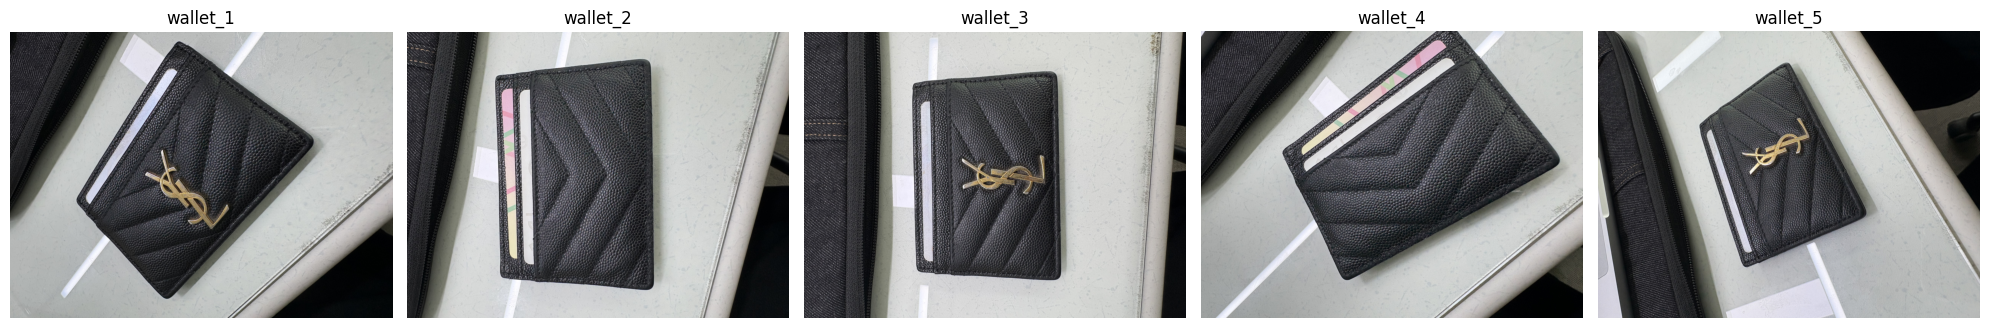

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(images):
    axes[i].imshow(image)
    axes[i].set_title(f"wallet_{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 6. SigLIP2 모델 로드


In [8]:
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

siglip_model_id = "google/siglip2-base-patch16-224"

siglip_processor = AutoProcessor.from_pretrained(
    siglip_model_id
)

siglip_model = AutoModel.from_pretrained(
    siglip_model_id,
    torch_dtype=torch.float16
).to(device)

siglip_model.eval()

print("SigLIP2 loaded!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP2 loaded!


## 7. SigLIP2 임베딩 함수 정의


In [9]:
def get_siglip_embedding(image):
    inputs = siglip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = siglip_model.get_image_features(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 8. 민준 지갑 5장의 SigLIP2 임베딩 생성


In [10]:
siglip_embeddings = [
    get_siglip_embedding(image)
    for image in images
]

print("SigLIP2 embedding 개수:", len(siglip_embeddings))
print("Embedding shape:", siglip_embeddings[0].shape)

SigLIP2 embedding 개수: 5
Embedding shape: torch.Size([1, 768])


## 9. 민준지갑_01 기준 SigLIP2 코사인 유사도


In [11]:
print("===== SigLIP2 =====")

for i in range(5):
    score = F.cosine_similarity(
        siglip_embeddings[0],
        siglip_embeddings[i]
    ).item()

    print(
        f"wallet_01 ↔ wallet_{i+1:02d}: {score:.4f}"
    )

===== SigLIP2 =====
wallet_01 ↔ wallet_01: 0.9995
wallet_01 ↔ wallet_02: 0.8608
wallet_01 ↔ wallet_03: 0.9604
wallet_01 ↔ wallet_04: 0.8799
wallet_01 ↔ wallet_05: 0.9463


## 10. DINOv2 모델 로드


In [12]:
from transformers import AutoImageProcessor, AutoModel

dino_model_id = "facebook/dinov2-base"

dino_processor = AutoImageProcessor.from_pretrained(
    dino_model_id
)

dino_model = AutoModel.from_pretrained(
    dino_model_id
).to(device)

dino_model.eval()

print("DINOv2 loaded!")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded!


## 11. DINOv2 임베딩 함수 정의


In [13]:
def get_dino_embedding(image):
    inputs = dino_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = dino_model(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 12. 민준 지갑 5장의 DINOv2 임베딩 생성


In [14]:
dino_embeddings = [
    get_dino_embedding(image)
    for image in images
]

print("DINOv2 embedding 개수:", len(dino_embeddings))
print("Embedding shape:", dino_embeddings[0].shape)

DINOv2 embedding 개수: 5
Embedding shape: torch.Size([1, 768])


## 13. 민준지갑_01 기준 DINOv2 코사인 유사도


In [15]:
print("===== DINOv2 =====")

for i in range(5):
    score = F.cosine_similarity(
        dino_embeddings[0],
        dino_embeddings[i]
    ).item()

    print(
        f"wallet_01 ↔ wallet_{i+1:02d}: {score:.4f}"
    )

===== DINOv2 =====
wallet_01 ↔ wallet_01: 1.0000
wallet_01 ↔ wallet_02: 0.7782
wallet_01 ↔ wallet_03: 0.7938
wallet_01 ↔ wallet_04: 0.8009
wallet_01 ↔ wallet_05: 0.8665


## 실험 1 종료

이 파일은 **동일한 실제 지갑의 촬영 각도 변화에 대한 유사도 확인**까지만 포함한다.
다른 지갑을 후보군에 섞은 Retrieval 평가는 실험 2에서 수행한다.
